In [19]:
import pandas as pd
import os
import json
import glob

# Define the path to the directory containing the JSON files
metrics_dir = 'epoch_metrics'

# Get a list of all JSON file paths in the directory
json_files = glob.glob(os.path.join(metrics_dir, '*.json'))

# Initialize an empty list to store all metrics
all_metrics = []

# Iterate through each JSON file
for file_path in json_files:
    # Open the file and read it line by line
    with open(file_path, 'r') as f:
        for line in f:
            # Skip empty lines
            if not line.strip():
                continue
            # Replace single quotes with double quotes to ensure valid JSON format
            valid_json_string = line.replace("'", '"')
            try:
                # Load the JSON object from the line
                data = json.loads(valid_json_string)
                all_metrics.append(data)
            except json.JSONDecodeError as e:
                print(f"Could not parse line in {file_path}: {e}")

# Create a DataFrame from the list of dictionaries
df = pd.DataFrame(all_metrics)

# Display the first few rows of the DataFrame
df.groupby('gpu_name').head(3)

,experiment_num,gpu_vendor,gpu_name,model,precision,batch_size,epoch,loss,epoch_time_sec,samples,samples_per_sec,nan_inf_count_so_far,skipped_steps_so_far,mem_alloc_bytes,mem_reserved_bytes,max_mem_alloc_bytes,max_mem_reserved_bytes,gpu_util_percent,mem_util_percent,power_watts
0,1,nvidia,NVIDIA L40S,resnet50,fp16,96,1,2.306783,8.289907,9600,1158.034707,0,0,457887744,5289017344,4667542016,5289017344,98,91,315.619
1,1,nvidia,NVIDIA L40S,resnet50,fp16,96,2,2.294169,7.905766,9600,1214.303511,0,0,457887744,5289017344,4667542016,5289017344,97,91,311.423
2,1,nvidia,NVIDIA L40S,resnet50,fp16,96,3,2.311544,7.902498,9600,1214.805784,0,0,457887744,5289017344,4667542016,5289017344,97,92,317.180
1000,1,amd,Radeon RX 7900 XT,bert-large,fp32,64,1,0.717228,246.106751,6400,26.004975,0,0,5399178752,18545115136,17584234496,18545115136,98,18913345536,263.000
1001,1,amd,Radeon RX 7900 XT,bert-large,fp32,64,2,0.767520,246.184972,6400,25.996713,0,0,5399178752,18545115136,17584234496,18545115136,98,18913345536,266.000
1002,1,amd,Radeon RX 7900 XT,bert-large,fp32,64,3,0.691625,246.062723,6400,26.009628,0,0,5399178752,18545115136,17584234496,18545115136,98,18913345536,264.000
1349,1,nvidia,NVIDIA GeForce RTX 4090,resnet50,bf16,192,1,2.318115,15.864912,19200,1210.217885,0,0,518018560,10240393216,8968310272,10240393216,99,88,356.451
1350,1,nvidia,NVIDIA GeForce RTX 4090,resnet50,bf16,192,2,2.308187,15.255458,19200,1258.565980,0,0,518018560,10240393216,8968310272,10240393216,99,89,357.290
1351,1,nvidia,NVIDIA GeForce RTX 4090,resnet50,bf16,192,3,2.305094,15.257847,19200,1258.368865,0,0,518018560,10240393216,8968310272,10240393216,99,89,358.475


In [20]:
# For a more stable analysis, let's filter out the initial warm-up epochs (e.g., first 10 epochs).
df_analysis = df[df['epoch'] > 10].copy()

# Calculate a power efficiency metric: samples per second per watt.
# Add a small epsilon to power_watts to avoid division by zero, just in case.
df_analysis['samples_per_watt'] = df_analysis['samples_per_sec'] / (df_analysis['power_watts'] + 1e-6)

# Group by GPU, model, and precision, then calculate the mean of key performance and efficiency metrics.
analysis_results = df_analysis.groupby(['gpu_name', 'model', 'precision']).agg(
    avg_samples_per_sec=('samples_per_sec', 'mean'),
    avg_power_watts=('power_watts', 'mean'),
    avg_samples_per_watt=('samples_per_watt', 'mean'),
    max_batch_size=('batch_size', 'max')
).round(2)

# Display the analysis results
print("GPU Performance and Efficiency Analysis (mean values, epochs > 10):")
analysis_results

GPU Performance and Efficiency Analysis (mean values, epochs > 10):


avg_samples_per_sec  \
gpu_name                model      precision                        
NVIDIA GeForce RTX 4090 bert-large bf16                    363.03   
                                   fp16                    356.41   
                                   fp32                    229.75   
                        gpt2       bf16                    417.80   
                                   fp16                    411.09   
                                   fp32                    333.93   
                        resnet50   bf16                   1258.74   
                                   fp16                   1323.90   
                                   fp32                    717.78   
NVIDIA L40S             bert-large bf16                    368.64   
                                   fp16                    362.98   
                                   fp32                    237.25   
                        gpt2       bf16                    376.57   
                                   fp16                    362.36   
                                   fp32                    317.84   
                        resnet50   bf16                   1187.06   
                                   fp16                   1213.79   
                                   fp32                    683.79   
Radeon RX 7900 XT       bert-large bf16                    161.42   
                                   fp16                    172.58   
                                   fp32                     25.92   
                        gpt2       bf16                    255.75   
                                   fp16                    253.21   
                                   fp32                     66.06   
                        resnet50   bf16                    393.20   
                                   fp16                    601.17   
                                   fp32                    289.12   

                                              avg_power_watts  \
gpu_name                model      precision                    
NVIDIA GeForce RTX 4090 bert-large bf16                367.71   
                                   fp16                362.09   
                                   fp32                428.16   
                        gpt2       bf16                350.91   
                                   fp16                351.15   
                                   fp32                349.25   
                        resnet50   bf16                357.17   
                                   fp16                332.32   
                                   fp32                352.96   
NVIDIA L40S             bert-large bf16                315.79   
                                   fp16                312.81   
                                   fp32                330.77   
                        gpt2       bf16                314.37   
                                   fp16                309.48   
                                   fp32                307.99   
                        resnet50   bf16                319.19   
                                   fp16                314.76   
                                   fp32                313.70   
Radeon RX 7900 XT       bert-large bf16                266.61   
                                   fp16                269.00   
                                   fp32                261.59   
                        gpt2       bf16                268.41   
                                   fp16                267.28   
                                   fp32                261.06   
                        resnet50   bf16                257.67   
                                   fp16                261.69   
                                   fp32                262.51   

                                              avg_samples_per_watt  \
gpu_name                model      precision                         
NVIDIA GeForce RTX

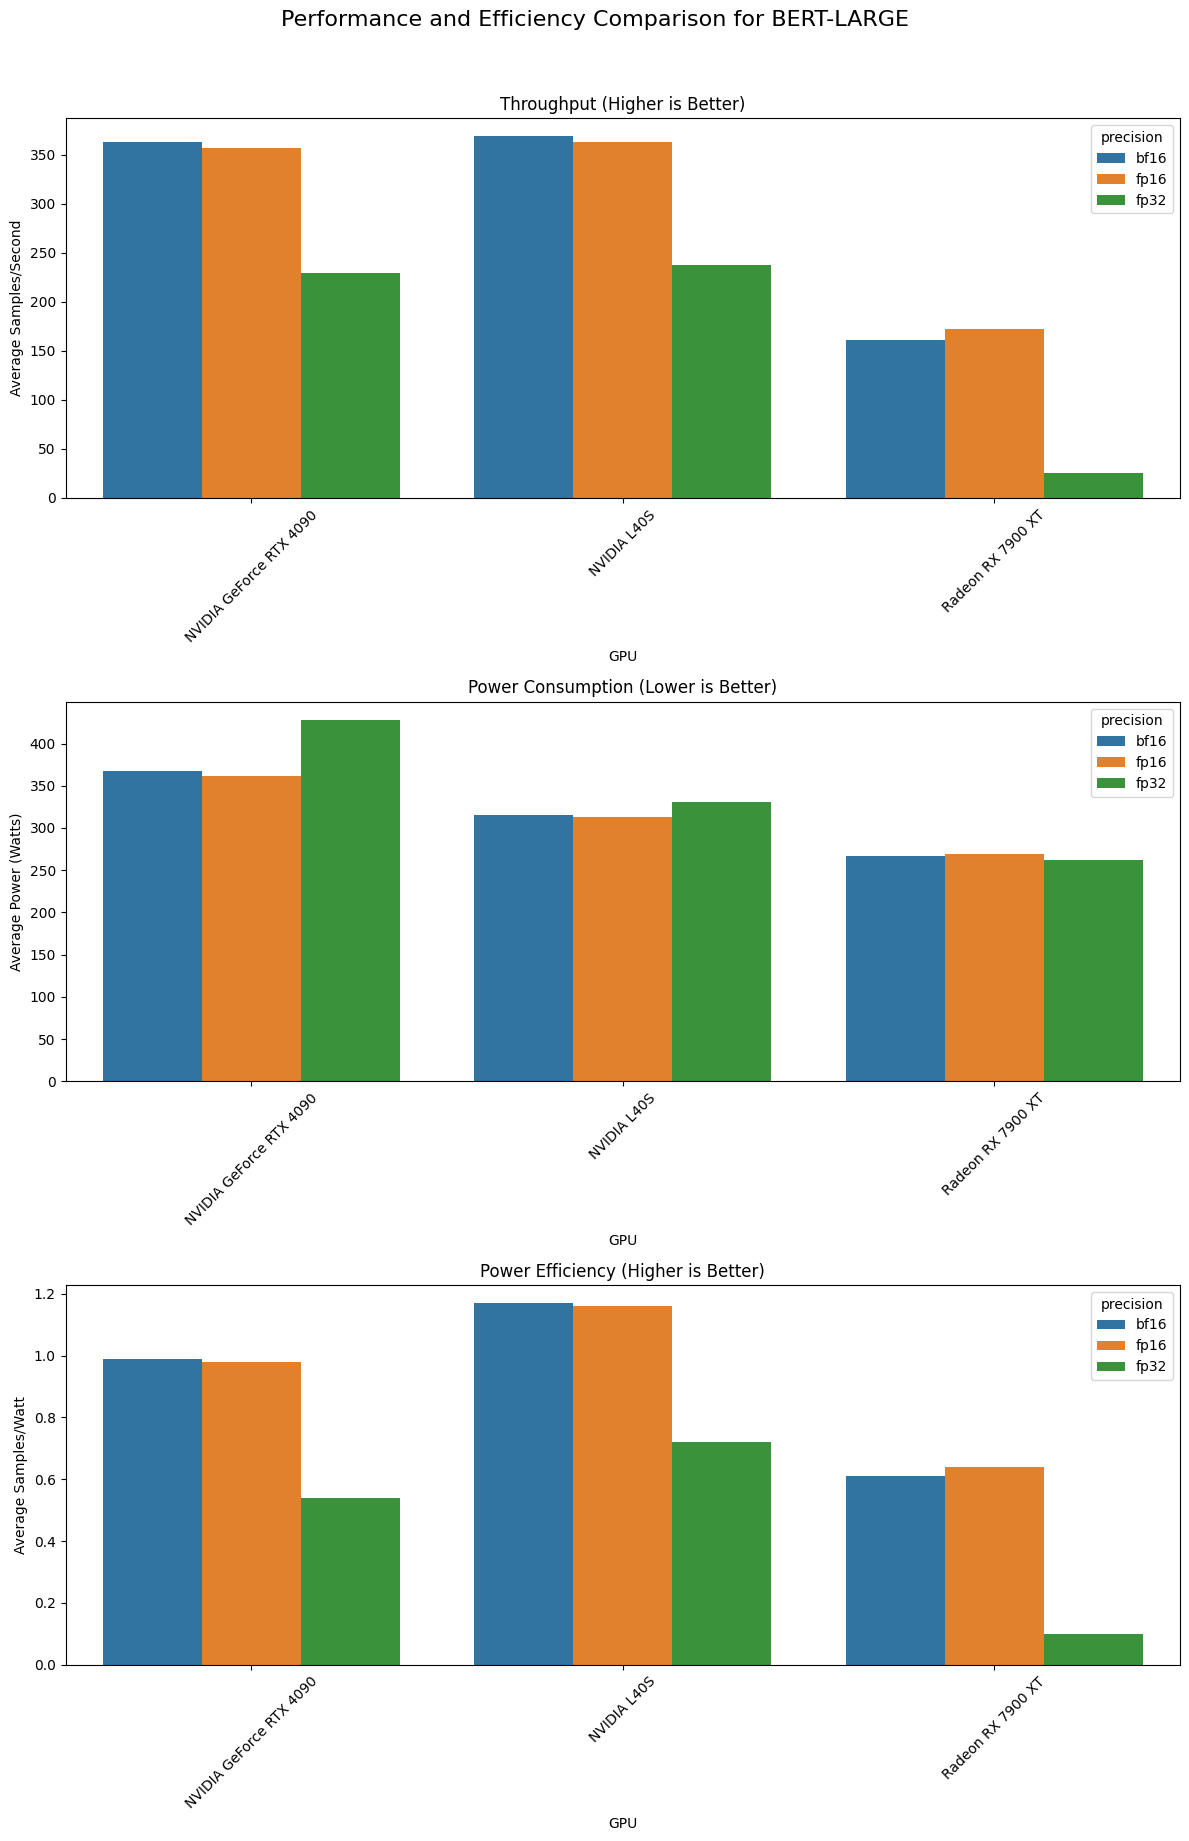

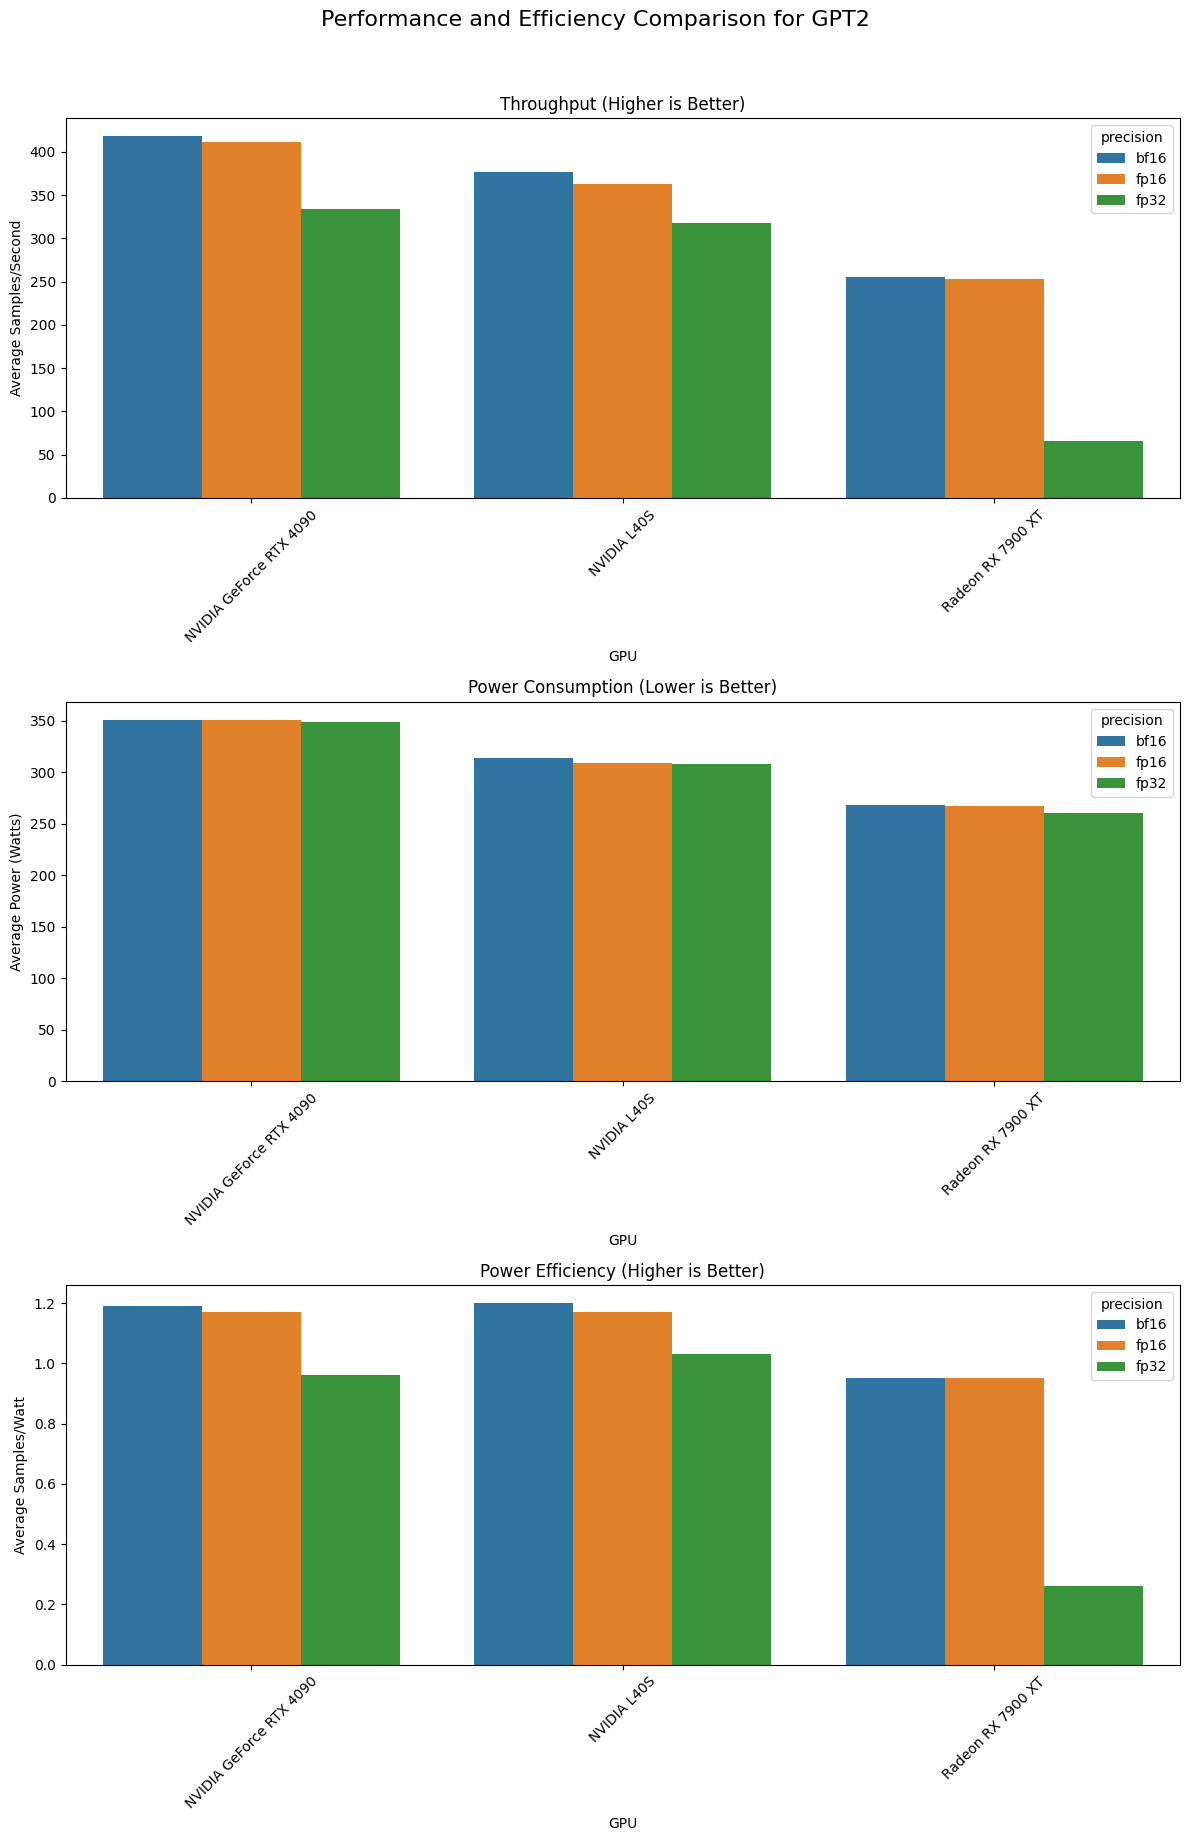

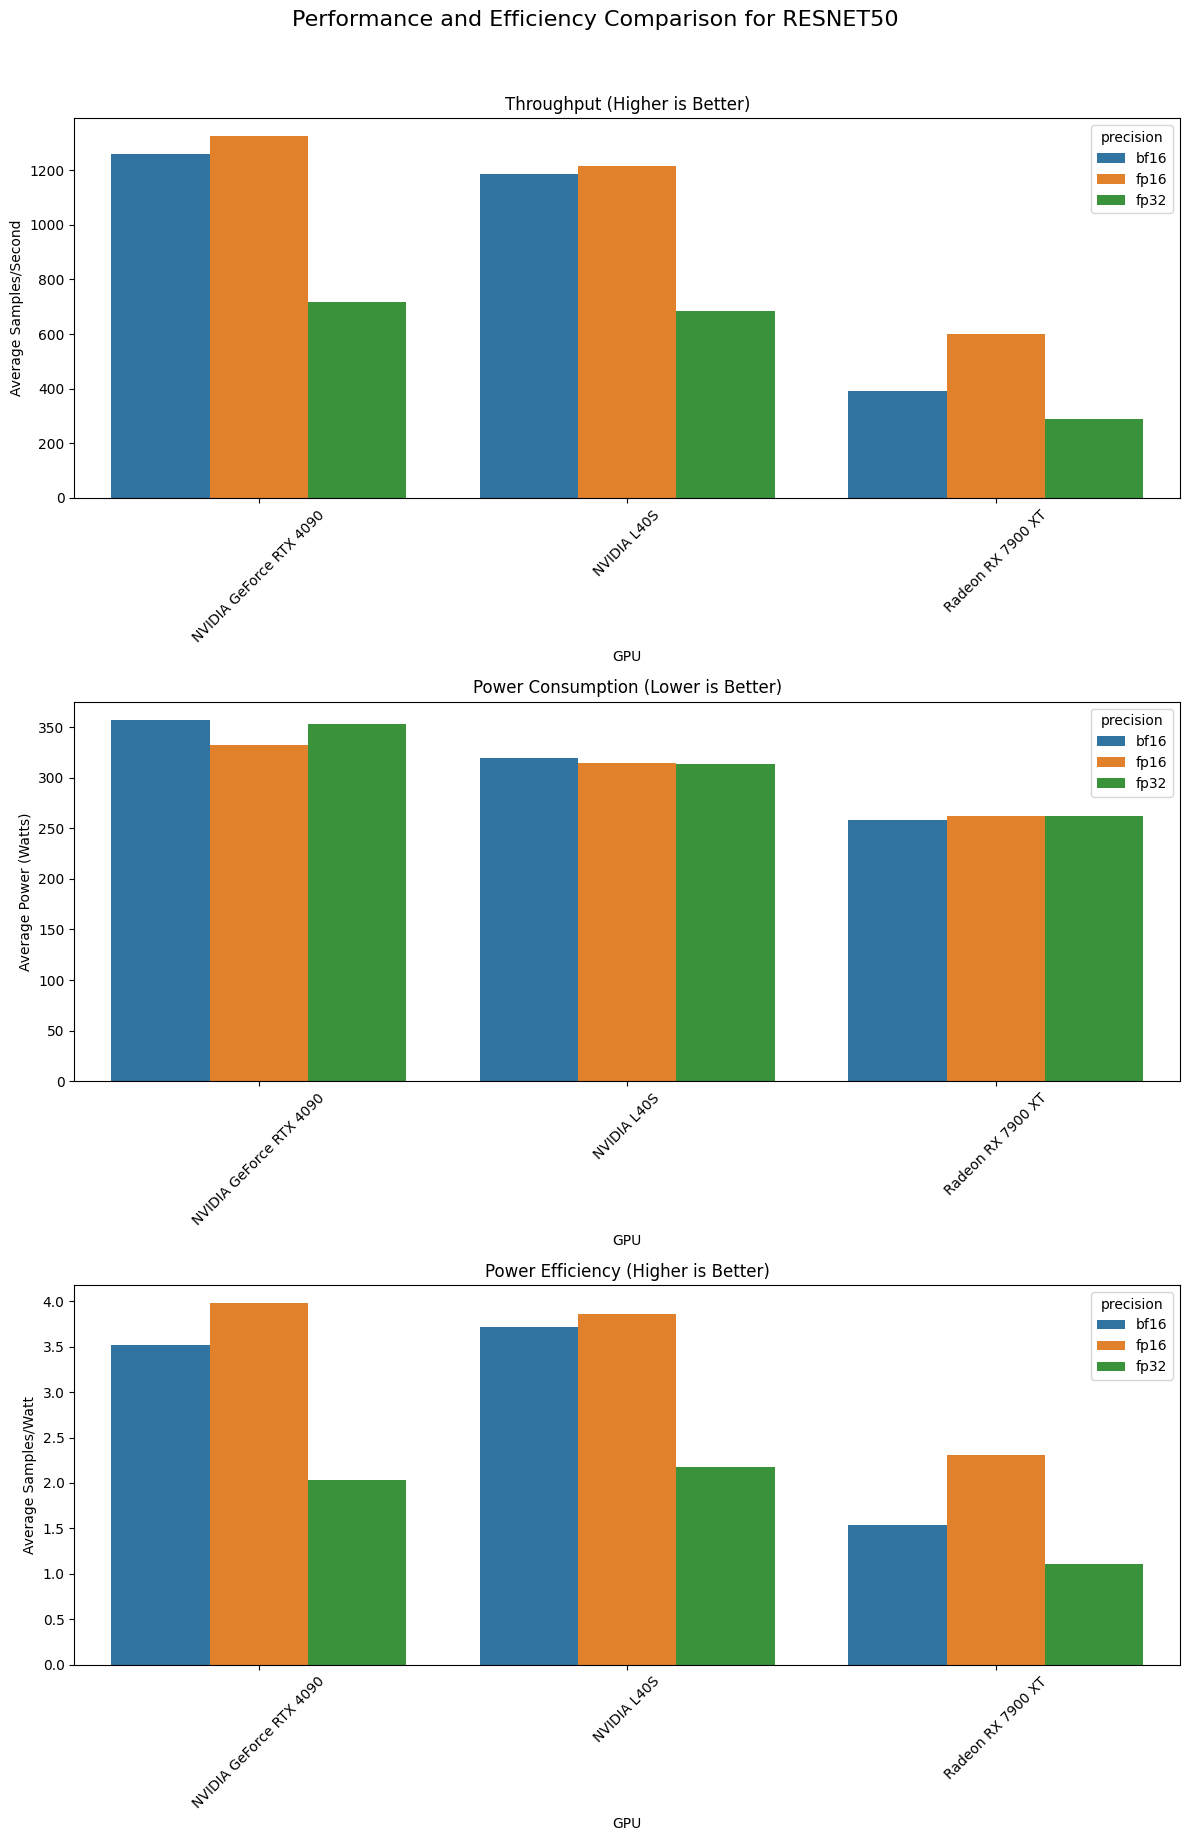

In [21]:
import seaborn as sns

import matplotlib.pyplot as plt

# Prepare data for plotting
plot_data = analysis_results.reset_index()

# Get the unique models to create separate plots for each
models = plot_data['model'].unique()

for model_name in models:
    # Filter data for the current model
    model_data = plot_data[plot_data['model'] == model_name]
    
    # Create a figure with 3 subplots
    fig, axes = plt.subplots(3, 1, figsize=(12, 18))
    fig.suptitle(f'Performance and Efficiency Comparison for {model_name.upper()}', fontsize=16, y=1.02)
    
    # Plot 1: Average Samples per Second (Throughput)
    sns.barplot(data=model_data, x='gpu_name', y='avg_samples_per_sec', hue='precision', ax=axes[0])
    axes[0].set_title('Throughput (Higher is Better)')
    axes[0].set_ylabel('Average Samples/Second')
    axes[0].set_xlabel('GPU')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Plot 2: Average Power Consumption
    sns.barplot(data=model_data, x='gpu_name', y='avg_power_watts', hue='precision', ax=axes[1])
    axes[1].set_title('Power Consumption (Lower is Better)')
    axes[1].set_ylabel('Average Power (Watts)')
    axes[1].set_xlabel('GPU')
    axes[1].tick_params(axis='x', rotation=45)

    # Plot 3: Samples per Watt (Efficiency)
    sns.barplot(data=model_data, x='gpu_name', y='avg_samples_per_watt', hue='precision', ax=axes[2])
    axes[2].set_title('Power Efficiency (Higher is Better)')
    axes[2].set_ylabel('Average Samples/Watt')
    axes[2].set_xlabel('GPU')
    axes[2].tick_params(axis='x', rotation=45)
    
    # Adjust layout and display the plots
    plt.tight_layout()
    plt.show()